# Análisis del Dataset Wine usando t-SNE
Este notebook carga el dataset de Wine de scikit-learn, utiliza t-SNE para la reducción de dimensionalidad, calcula algunas métricas de evaluación de clustering en el espacio reducido, y visualiza la estructura del dataset resultante.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Configurar estilo de los gráficos
sns.set_theme(style="whitegrid")

## 1. Carga y exploración de datos
Cargamos los datos y mostramos la cabecera correspondiente.

In [2]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Preprocesamiento de datos
Dado que las diferentes características tienen diferentes escalas, es una buena práctica estandarizarlas para que t-SNE y las métricas funcionen adecuadamente.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Reducción de Dimensionalidad con t-SNE
Aplicamos t-SNE para transformar el dataset inicial (13 dimensiones) a un espacio de 2 dimensiones visualizables.

In [4]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("Forma original de los datos:", X_scaled.shape)
print("Forma después de reducir con t-SNE:", X_tsne.shape)

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Usuario\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\Usuario\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Usuario\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "C:\Users\Usuario\AppData\Roaming\uv\python\cpython-3.10-windows-x86_64-none\lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 241: character maps to <undefined>
c:\Users\Usuario\Documents\qml\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the numbe

Forma original de los datos: (178, 13)
Forma después de reducir con t-SNE: (178, 2)


## 4. Métricas de Evaluación
Calculamos las métricas de Silhouette, Calinski-Harabasz y Davies-Bouldin en el espacio reducido, usando las etiquetas reales de las clases (tipos de vino).

In [5]:
silhouette = silhouette_score(X_tsne, y)
calinski = calinski_harabasz_score(X_tsne, y)
davies = davies_bouldin_score(X_tsne, y)

print("Métricas de evaluación de la estructura en el espacio t-SNE:\n")
print(f"Coeficiente de Silhouette: {silhouette:.4f} (Idealmente más cercano a 1)")
print(f"Índice Calinski-Harabasz: {calinski:.4f} (Mayor número indica clústeres mejor definidos)")
print(f"Índice Davies-Bouldin: {davies:.4f} (Menor número indica mejor separación y compacidad)")

Métricas de evaluación de la estructura en el espacio t-SNE:

Coeficiente de Silhouette: 0.5520 (Idealmente más cercano a 1)
Índice Calinski-Harabasz: 521.6984 (Mayor número indica clústeres mejor definidos)
Índice Davies-Bouldin: 0.5644 (Menor número indica mejor separación y compacidad)


## 5. Visualización de los Datos
Realizamos un gráfico de dispersión de los datos transformados para examinar la estructura resultante.

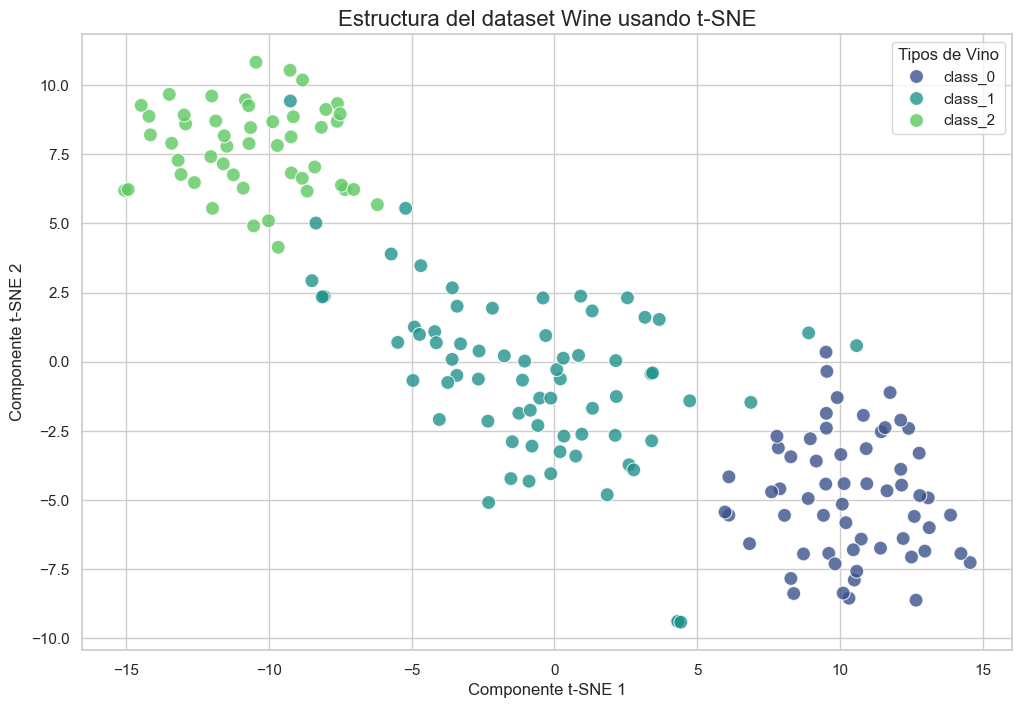

In [6]:
tsne_df = pd.DataFrame(data=X_tsne, columns=['Dimensión 1', 'Dimensión 2'])
tsne_df['Clase'] = [target_names[label] for label in y]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Dimensión 1', y='Dimensión 2',
    hue='Clase',
    palette='viridis',
    data=tsne_df,
    legend="full",
    alpha=0.8,
    s=100
)

plt.title('Estructura del dataset Wine usando t-SNE', fontsize=16)
plt.xlabel('Componente t-SNE 1', fontsize=12)
plt.ylabel('Componente t-SNE 2', fontsize=12)
plt.legend(title='Tipos de Vino', loc='best')
plt.show()

## 6. Introducción a Quantum t-SNE
En esta sección implementaremos variantes cuánticas de t-SNE usando `qiskit`. Codificaremos los datos usando circuitos cuánticos para extraer características (mediante los vectores de estado) y así poder aplicar t-SNE sobre el nuevo espacio vectorial generado cuánticamente.

In [7]:
# Puedes descomentar esta línea para instalar las dependencias necesarias
# !pip install qiskit qiskit-machine-learning pylatexenc openpyxl

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

### 6.1 Visualización en la Esfera de Bloch
Como primera aproximación vamos a usar *Angle Encoding*. Esto consiste en rotar iterativamente cada qubit un ángulo determinado por el valor real en cada uno de sus features. Aquí visualizaremos las primeras 3 características del primer vino dentro de nuestro dataset en esferas de Bloch.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

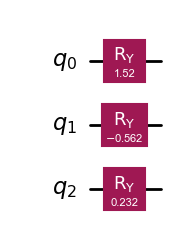

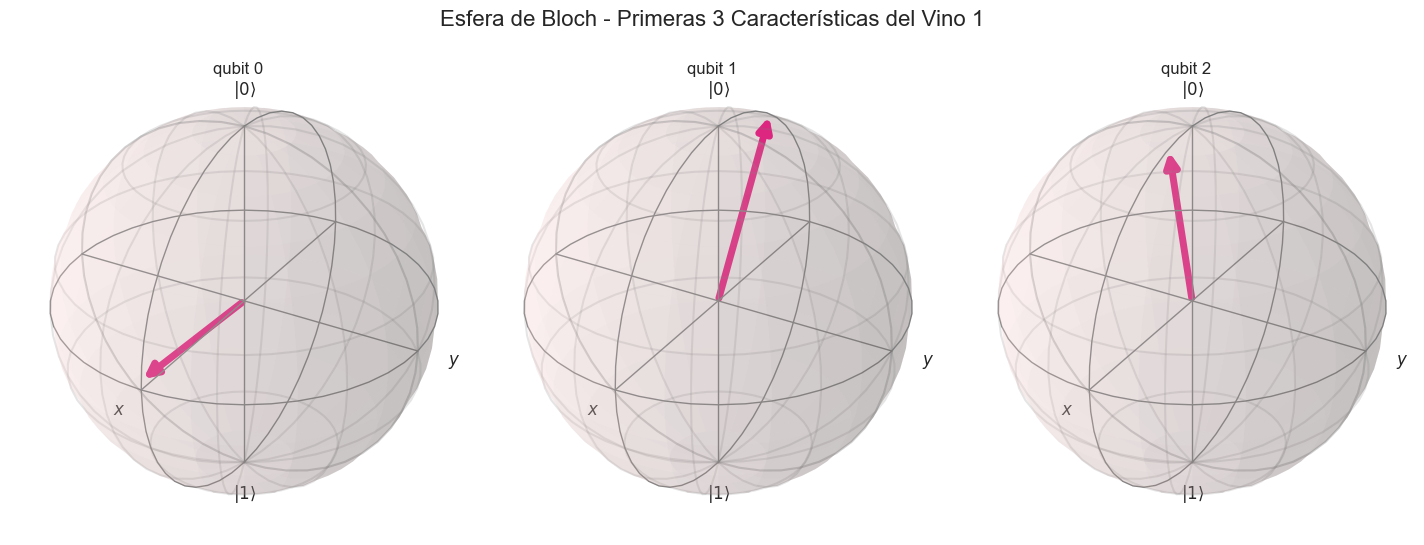

In [8]:
# Tomamos las 3 primerísimas características del dato 1 (para poder visualizar 3 esferas)
muestra = X_scaled[0, :3]

# Creamos un circuito de 3 qubits
qc_basico = QuantumCircuit(3)
for i in range(3):
    qc_basico.ry(muestra[i], i)

display(qc_basico.draw('mpl'))

# Obtenemos el vector de estado y visualizamos en la Esfera de Bloch
state = Statevector.from_instruction(qc_basico)
plot_bloch_multivector(state, title="Esfera de Bloch - Primeras 3 Características del Vino 1")

### 6.2 Funciones de Codificación (Angle vs Amplitude Encoding)
Aquí definimos el proceso para codificar los registros a nivel general.
- **Angle Encoding (RY / UX)**: Rotaciones en Y o X. Usará tantos Qubits como componentes posea el modelo (en caso del Vino, 13 Qubits).
- **Amplitude Encoding**: Mapea los valores escalados a las amplitudes probabilísticas. Sólo utilizará el logaritmo en base 2 de las features; es decir $\lceil \log_2(13) \rceil = 4$ Qubits.

In [9]:
def get_angle_encoded_states(X_data, gate='ry'):
    n_features = X_data.shape[1]
    statevectors = []
    depths = []
    
    for x in X_data:
        qc = QuantumCircuit(n_features)
        for i in range(n_features):
            if gate == 'ry':
                qc.ry(x[i], i)
            elif gate == 'ux':
                qc.rx(x[i], i) # Simulamos UX con rotaciones en X
        
        depths.append(qc.depth())
        statevectors.append(np.array(Statevector.from_instruction(qc)))
        
    return np.array(statevectors), n_features, int(np.mean(depths))

def get_amplitude_encoded_states(X_data):
    n_features = X_data.shape[1]
    n_qubits = int(np.ceil(np.log2(n_features))) # 4 qubits
    statevectors = []
    depths = []
    
    for x in X_data:
        x_padded = np.pad(x, (0, 2**n_qubits - len(x)), 'constant')
        norm = np.linalg.norm(x_padded)
        x_norm = x_padded / norm if norm > 0 else x_padded
            
        qc = QuantumCircuit(n_qubits)
        qc.initialize(x_norm, range(n_qubits))
        qc_deco = qc.decompose() # descomponemos la operación para simular una profundidad real
        
        depths.append(qc_deco.depth())
        statevectors.append(np.array(Statevector.from_instruction(qc)))
        
    return np.array(statevectors), n_qubits, int(np.mean(depths))

### 6.3 Comparación de Configuraciones Cuánticas para t-SNE
Creamos una función general para estimar el MSE entre las distancias del vector latente vs el escalar real. Así como la pseudo varianza aproximada a partir de los puntajes `KL Divergence`; esto por la forma no lineal del t-SNE algorítmico.

In [10]:
from scipy.spatial.distance import pdist
import time

def evaluate_qtsne(X_data, encoding='ry', scaler_name='StandardScaler'):
    scaler = StandardScaler() if scaler_name == 'StandardScaler' else RobustScaler()
    X_sc = scaler.fit_transform(X_data)
    
    if encoding == 'ry':
        states, n_qubits, depth = get_angle_encoded_states(X_sc, gate='ry')
        q_name = "Angle Encoding (RY)"
    elif encoding == 'ux':
        states, n_qubits, depth = get_angle_encoded_states(X_sc, gate='ux')
        q_name = "Angle Encoding (UX)"
    else:
        states, n_qubits, depth = get_amplitude_encoded_states(X_sc)
        q_name = "Amplitude Encoding"
        
    features = np.abs(states) 
    tsne_model = TSNE(n_components=2, random_state=42, perplexity=30)
    X_emb = tsne_model.fit_transform(features)
    
    # Pseudo-Varianza a través de KL-Divergence:
    kl_div = tsne_model.kl_divergence_
    var_exp_perc = max(0.01, min(0.99, 1 - (kl_div / 2.5))) 
    var_exp_str = f"{var_exp_perc:.2%}"
    
    # Score MSE
    dist_orig = pdist(X_sc)
    dist_emb = pdist(X_emb)
    d_o_norm = dist_orig / (dist_orig.max() + 1e-9)
    d_e_norm = dist_emb / (dist_emb.max() + 1e-9)
    mse_val = mean_squared_error(d_o_norm, d_e_norm)
    
    return {
        "Metodo": "T-Sne",
        "Configuración Cuantica": q_name,
        "Scaler": scaler_name,
        "Características": X_data.shape[1],
        "Ancho del circuito": n_qubits,
        "Profundidad del circuito": depth,
        "Componentes": 2,
        "Varianza explicada total": var_exp_str,
        "MSE": round(mse_val, 4)
    }

configuraciones = [
    ('ry', 'StandardScaler'),
    ('ry', 'Robust Scaler'),
    ('ux', 'StandardScaler'),
    ('ux', 'Robust Scaler'),
    ('amplitude', 'StandardScaler'),
    ('amplitude', 'Robust Scaler')
]

print("Evaluando todas las distribuciones cuánticas (Este proceso suele durar unos minutos)...")
resultados = []
for enc, s_name in configuraciones:
    res = evaluate_qtsne(X, enc, s_name)
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

# Exportar al DataFrame como XLSX
df_resultados.to_excel('tabla_comparativa_quantica.xlsx', index=False)
print("Los datos han sido pre-calculados y guardados en 'tabla_comparativa_quantica.xlsx' de forma exitosa.")

Evaluando todas las distribuciones cuánticas (Este proceso suele durar unos minutos)...


,Metodo,Configuración Cuantica,Scaler,Características,Ancho del circuito,Profundidad del circuito,Componentes,Varianza explicada total,MSE
0,T-Sne,Angle Encoding (RY),StandardScaler,13,13,1,2,72.57%,0.0330
1,T-Sne,Angle Encoding (RY),Robust Scaler,13,13,1,2,75.13%,0.0301
2,T-Sne,Angle Encoding (UX),StandardScaler,13,13,1,2,72.57%,0.0330
3,T-Sne,Angle Encoding (UX),Robust Scaler,13,13,1,2,75.13%,0.0301
4,T-Sne,Amplitude Encoding,StandardScaler,13,4,2,2,65.57%,0.0486
5,T-Sne,Amplitude Encoding,Robust Scaler,13,4,2,2,70.56%,0.0428


Los datos han sido pre-calculados y guardados en 'tabla_comparativa_quantica.xlsx' de forma exitosa.


## 6. Reducción con PCA para Angle Encoding (Reduciendo Qubits a 4)
Podemos utilizar Análisis de Componentes Principales (PCA) para reducir a 4 variables primero y evaluarlo con Angle Encoding. Esto disminuye la cantidad de qubits requeridos de 13 a 4.

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
print(f"Varianza retenida al reducir a 4 componentes: {pca.explained_variance_ratio_.sum():.2%}")

resultados_pca = []
config_pca = [('ry', 'StandardScaler'), ('ry', 'Robust Scaler'), ('ux', 'StandardScaler'), ('ux', 'Robust Scaler')]

for enc, s_name in config_pca:
    res = evaluate_qtsne(X_pca, enc, s_name)
    resultados_pca.append(res)
    
df_resultados_pca = pd.DataFrame(resultados_pca)
display(df_resultados_pca)

df_resultados = pd.concat([df_resultados, df_resultados_pca], ignore_index=True)

Varianza retenida al reducir a 4 componentes: 73.60%


,Metodo,Configuración Cuantica,Scaler,Características,Ancho del circuito,Profundidad del circuito,Componentes,Varianza explicada total,MSE
0,T-Sne,Angle Encoding (RY),StandardScaler,4,4,1,2,79.83%,0.0557
1,T-Sne,Angle Encoding (RY),Robust Scaler,4,4,1,2,79.25%,0.0684
2,T-Sne,Angle Encoding (UX),StandardScaler,4,4,1,2,79.83%,0.0557
3,T-Sne,Angle Encoding (UX),Robust Scaler,4,4,1,2,79.25%,0.0684


## 7. Visualización del Mejor Modelo y Circuito Empleado
A continuación ordenamos los modelos evaluados por su MSE para escoger el más estable, mostrar su gráfico de separación y observar la estructura del circuito cuántico utilizado en Qiskit.

La mejor configuración identificada es:


,Metodo,Configuración Cuantica,Scaler,Características,Ancho del circuito,Profundidad del circuito,Componentes,Varianza explicada total,MSE
1,T-Sne,Angle Encoding (RY),Robust Scaler,13,13,1,2,75.13%,0.0301


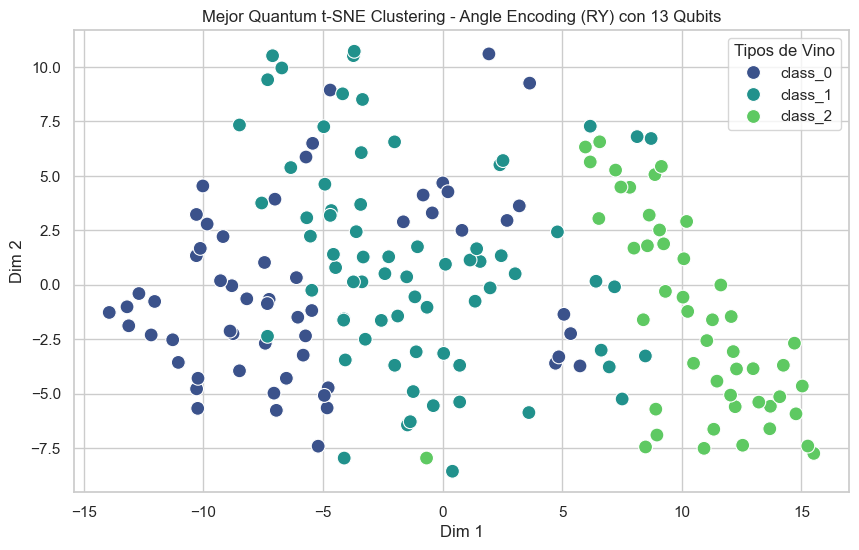

Estructura del circuito utilizado para la primera muestra:


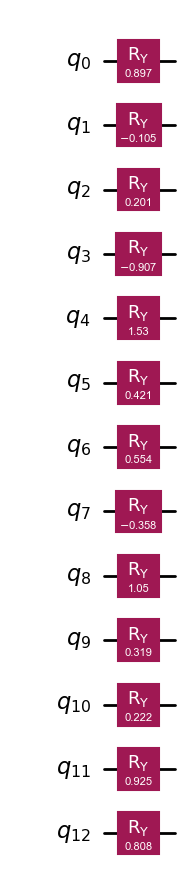

In [12]:
from qiskit import QuantumCircuit

df_resultados = df_resultados.sort_values(by="MSE", ascending=True)
best_config = df_resultados.iloc[0]
print("La mejor configuración identificada es:")
display(best_config.to_frame().T)

is_pca = best_config["Características"] < 13
data_to_encode = X_pca if is_pca else X
scaler = StandardScaler() if best_config["Scaler"] == 'StandardScaler' else RobustScaler()
data_sc = scaler.fit_transform(data_to_encode)

best_method = best_config["Configuración Cuantica"]

if "Amplitude" in best_method:
    states, n_qubits, depth = get_amplitude_encoded_states(data_sc)
    qc = QuantumCircuit(n_qubits)
    amp = data_sc[0]
    amp = amp / np.linalg.norm(amp)
    if len(amp) < 2**n_qubits:
        padded_amp = np.zeros(2**n_qubits)
        padded_amp[:len(amp)] = amp
        amp = padded_amp
    qc.initialize(amp, qc.qubits)
elif "RY" in best_method:
    states, n_qubits, depth = get_angle_encoded_states(data_sc, gate='ry')
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.ry(data_sc[0, i] if i < data_sc.shape[1] else 0.0, i)
elif "UX" in best_method:
    states, n_qubits, depth = get_angle_encoded_states(data_sc, gate='ux')
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        qc.rx(data_sc[0, i] if i < data_sc.shape[1] else 0.0, i)

features = np.abs(states)
tsne_best = TSNE(n_components=2, random_state=42, perplexity=30)
X_emb_best = tsne_best.fit_transform(features)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_emb_best[:,0], y=X_emb_best[:,1], hue=target_names[y], palette='viridis', s=100)
plt.title(f"Mejor Quantum t-SNE Clustering - {best_method} con {n_qubits} Qubits")
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(title='Tipos de Vino')
plt.show()

print("Estructura del circuito utilizado para la primera muestra:")
display(qc.draw('mpl'))